### Graph Attention Networks (GATs)

This notebook demonstrates a key limitation of standard Graph Convolutional Networks (GCNs) and introduces Graph Attention Networks (GATs) as a solution.

Much of the discussion is based on:

- [Stanford CS224W, Lecture 7.2](https://www.youtube.com/watch?v=247Mkqj_wRM)
- *Hands-On Graph Neural Networks Using Python*, Maxime Labonne (2023)

I'm using the terminology from the Stanford course. I'll let you know if I'm using any code from other sources when I use it.



__A Problem with GCNs__

There is a problem with the GCN model as we have used it. The problem is that we have decided that the importance of a node in a network is given by its degree. We see this in the equations that show how to update a hidden layer give the previous hidden layer. I'll illustrate with the first hidden layer so that we don't have to keep track of all the superscripts thta indicate which layer we are dealing with.

$$ h_i = \frac{1}{k_i} \sum_{j\in N(i)} x_j $$

Notice that we are weighting all neighbors by node $i$'s degree. If we modify it so that we also use node $j$'s degree, the formulat is

$$ h_i = \frac{1}{\sqrt{k_i}} \sum_{j\in N(i)} \frac{1}{\sqrt{k_j}}x_j $$

which is the form that yielded the matrix update

$$ H = D^{-\frac{1}{2}}AD^{-\frac{1}{2}}X $$

Let's rewrite the second equation to give us some insight.

$$ h_i = \sum_{j\in N(i)} \frac{1}{\sqrt{k_i}\sqrt{k_j}}x_j $$

In this form, we see that the message passed from node $j$ to node $i$ is weighted by a fixed _importance parameter_ $\frac{1}{\sqrt{k_i}\sqrt{k_j}}$.   

This fixed importance factor means  _all neighbors contribute equally_, even if some are noisy or less relevant. What if we could _learn which neighbors matter_?

---

### GATs: Learn to Focus

Graph Attention Networks (GATs) modify the aggregation scheme:

$$
h_i = \sum_{j \in \mathcal{N}(i)} \alpha_{ij} x_j
$$

The importance factor $ \alpha_{ij} $ represents the "attention weight" for each edge $ i \to j $. These weights are computed using a shared attention mechanism, which allows the model to focus on the most relevant neighbors. The weights are adapted as learning occurs in the GNN.

This solves the GCN problem: _the importance of neighbors is no longer hardcoded — it's learned_.

Let's illustrate how to set up a GAT using the pinwheel network.

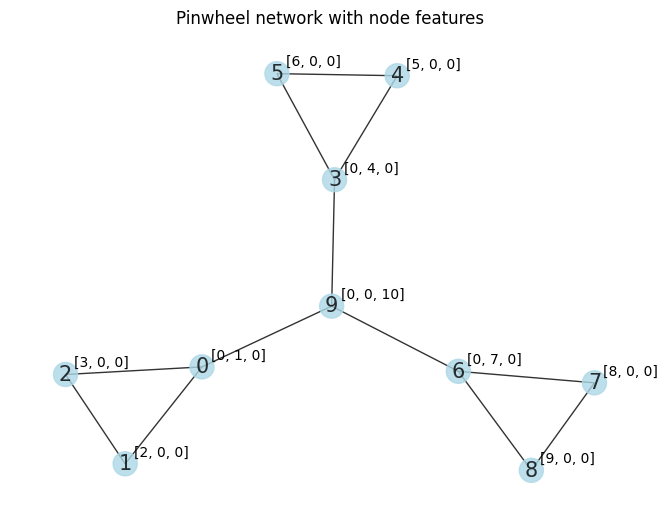

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
pinwheel_graph: nx.Graph = nx.Graph()
for i in range(0,10):  # give each node a feature. We'll set them in a minute.
    if i in {1,2,4,5,7,8}: 
        pinwheel_graph.add_node(i, feature = [i+1,0,0])
    elif i in {0,3,6}: 
        pinwheel_graph.add_node(i, feature = [0,i+1,0])
    else: 
        pinwheel_graph.add_node(i, feature = [0,0,i+1])
pinwheel_graph.add_edges_from([(0,1),(0,2),(1,2),(3,4),(3,5),(4,5),(6,7),(6,8),(7,8),(0,9),(3,9),(6,9)])
colormap = ['lightblue' for _ in pinwheel_graph.nodes()]
#pos = nx.nx_agraph.graphviz_layout(G,prog='neato')
pos = nx.nx_pydot.graphviz_layout(pinwheel_graph,prog="neato")
plt.figure()
plt.clf()
nx.draw(pinwheel_graph,pos,with_labels = True,node_color = colormap, node_size = 300,font_size = 15, alpha=0.8)
for node in pos.keys():
    plt.text(pos[node][0]+5, pos[node][1]+5, str(pinwheel_graph.nodes[node]['feature']))
_ = plt.title("Pinwheel network with node features")

The first thing we'll do is use a _linear layer_, which simply multiplies each feature vector by a weight. We'll do this in a matrix form, so let's begin by setting up the feature vector by stacking the (row) feature vectors. 

Represent the features of each node as a row vector:

$$ \vec{x}_i = \left[ \begin{array}{cccc}x_{i,1} & x_{i,2} & \ldots & x_{i,n} \end{array}\right] $$

Stack those feature vectors on top of each other to form a big matrix of features

$$ X = \left[ \begin{array}{c} \vec{x}_1 \\ \vec{x}_2 \\ \vdots \\ \vec{x}_n \end{array}\right] $$

Note that I've changed from boldface to indicate vectors to the format with little lines above the $x$. For some reason, that helps me more easily see that we are stacking row vectors.

In [2]:
import numpy as np
X = np.zeros((len(pinwheel_graph.nodes),len(pinwheel_graph.nodes[1]["feature"])))
for node in pinwheel_graph.nodes:
    X[node,:] = np.array(pinwheel_graph.nodes[node]["feature"])
print(X)

[[ 0.  1.  0.]
 [ 2.  0.  0.]
 [ 3.  0.  0.]
 [ 0.  4.  0.]
 [ 5.  0.  0.]
 [ 6.  0.  0.]
 [ 0.  7.  0.]
 [ 8.  0.  0.]
 [ 9.  0.  0.]
 [ 0.  0. 10.]]


__Weight Previous Layer__

We don't aggregate the messages yet. Instead, we transform them with a linear layer. Denote the input features as layer 0 and the first hidden layer as layer 1. 

Text(0.5, 1.0, 'Node features after weighting and before aggregating')

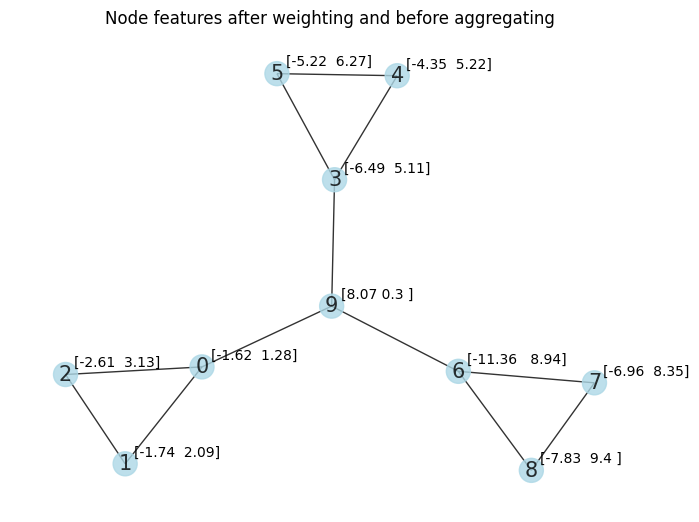

In [3]:
num_features_level0 = len(pinwheel_graph.nodes[1]["feature"])
num_features_level1 = 2
W = np.random.normal(size=(num_features_level0,num_features_level1))
H = X@W
plt.figure()
nx.draw(pinwheel_graph,pos,with_labels = True,node_color = colormap, node_size = 300,font_size = 15, alpha=0.8)
for node in pos.keys():
    plt.text(pos[node][0]+5, pos[node][1]+5, str(np.round(H[node,:],2)))
plt.title("Node features after weighting and before aggregating")

__Attention Coefficients and Attention Weights__

Our goal is to compute the the _attention weights_ $\alpha_{ij}$ for every edge $\{i,j\} \in E$. We do this by first computing _attention coefficients_, denoted by $e_{ij}$, and then "normalizing" that into the importance coefficient yielding

$$ \alpha_{ij} = \sigma(e_{ij})$$

You can think of this attention coefficient as how much node $i$ "pays attention to" its neighbor $j$ when messages are sent. We want the amount of attention given to be a function of the weighted features that we just derived. 

We'll begin with an abstract definition of the attention coefficient and then move to a specific implementation of the definition. Abstractly, the attention coefficient is defined as

$$ e_{ij} = g(\vec{x}_i{\mathbf W}, \vec{x}_j {\mathbf W})$$

where $g$ is a function that we need to create. Before continuing, let's review a few things we learned from the tutorial on GCNs.

---

In the GCN tutorial, we first tired to aggregate messages from our neighbors via 

$$ \begin{array}{rcl}
    {\mathbf h}_i &=& \frac{1}{k_i} \sum_{j\in N(i)} \vec{x}_j \\
    &=& \frac{1}{k_i} \sum_{j=1}^n A_{ij}\vec{x}_j
    \end{array}
$$

which in matrix form became

$$ 
H = D^{-1} A X 
$$  

When we applied this to the pinwheel network we got the following:

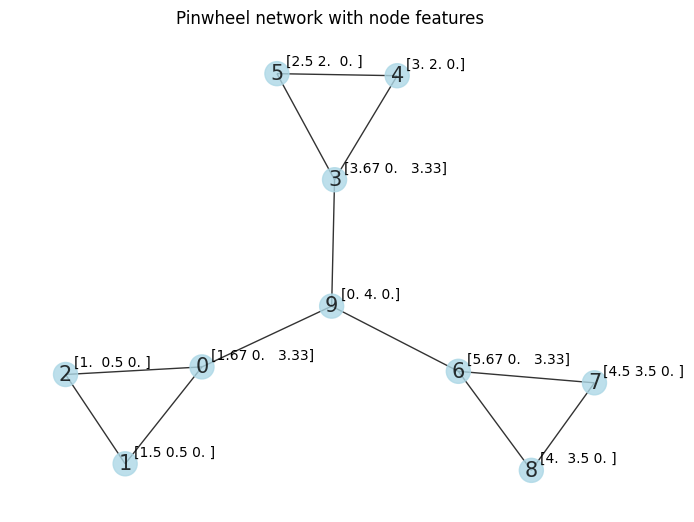

In [4]:
A = nx.linalg.adjacency_matrix(pinwheel_graph).toarray()
D = np.diag([pinwheel_graph.degree[node] for node in pinwheel_graph.nodes])
H = np.linalg.inv(D)@A@X
plt.figure()
nx.draw(pinwheel_graph,pos,with_labels = True,node_color = colormap, node_size = 300,font_size = 15, alpha=0.8)
for node in pos.keys():
    plt.text(pos[node][0]+5, pos[node][1]+5, str(np.round(H[node,:],2)))
_ = plt.title("Pinwheel network with node features")

The problem is that this aggregation forgot everything about the node's previous feature and just adopted the messages from neighbors. We illustrated this by looking how the feature for node 0 went from $[0\ 1\ 0]$ to $[1.67\ 0\ 3.33]$. 

---


**Self Loops Help a Node Remember**

We fixed the problem by telling the node to include its previous feature in the aggregation, which gave the equation

$$ H = \tilde{D}^{-1}\tilde{A} X $$

where the tilde indicated that we added self loops. This allowed the nodes to include their previous feature in the aggregation, yielding the following.

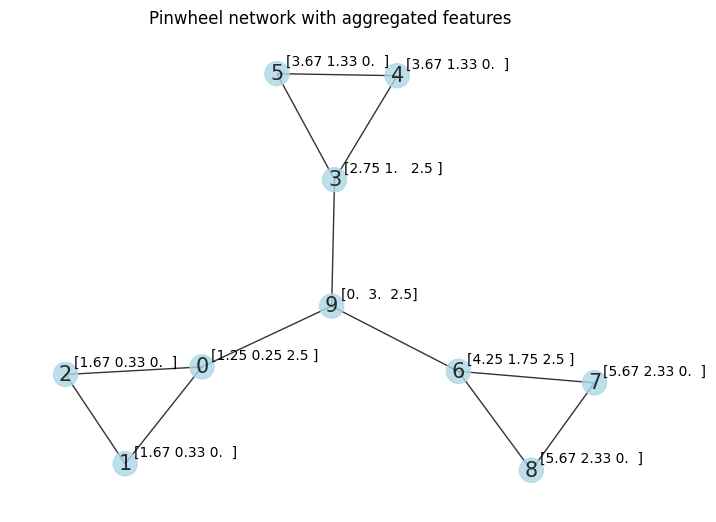

In [5]:
A = nx.linalg.adjacency_matrix(pinwheel_graph).toarray()
A = A + np.eye(len(A))
D = np.diag([pinwheel_graph.degree[node] for node in pinwheel_graph.nodes])
D = D + np.eye(len(D))
H = np.linalg.inv(D)@A@X

nx.draw(pinwheel_graph,pos,with_labels = True,node_color = colormap, node_size = 300,font_size = 15, alpha=0.8)
for node in pos.keys():
    plt.text(pos[node][0]+5, pos[node][1]+5, str(np.round(H[node,:],2)))
_ = plt.title("Pinwheel network with aggregated features")

**Edge Weights Should Blend Vertices at Both Ends**

We remember this lesson that a node should blend its own feature with the features of its neighbors. When we apply it to the  attention coefficient we get the equation

$$ e_{ij} = g(\vec{x}_i{\mathbf W}, \vec{x}_j{\mathbf W} )$$

which includes information from both me (node $i$) and my neighbor (node $j$).

In other words, the attention coefficient allows node $i$'s neighbors to have influence on node $i$ through $\vec{x}{\mathbf W}_j$, but it also makes sure that node $i$ includes its own feature to influence this assessment through $\vec{x}_i{\mathbf W}$. 

---


**Attention is an Edge Property**

Observe that $e_{ij}$ is a property of the edge between node $i$ and $j$. It was constructed by combining information from two nodes that share an edge. This is the first time we've used edge properties in the class beyond just the presence or absence of an edge.

Thus, we can think of the attention mechanism as a way of (a) defining an edge property between nodes and (b) using that edge property to shape learning. In the case of the attention coefficient, the edge property we define is based on how much a node should pay attention to each of its neighbors.

---

#### Implementing the Attention Coefficient

Both sources cited above use the implementation of the function $g$ from the original Graph Attention Networks paper,

```
    Velickovic, P., Cucurull, G., Casanova, A., Romero, A., Lio, P., & Bengio, Y. (2017). Graph attention networks. stat, 1050(20), 10-48550. Published as a paper at ICLR in 2018.
```

The implementation takes the two vectors ${\mathbf h}_i$ and ${\mathbf h}_j$ and concatenates them together. This is written using the symbol $\Vert$ to indicate concatenation. 

Let's illustrate by taking node 9's perspective. We'll construct the concatenated vector $\left[\vec{x}_9W \Vert \vec{x}_jW\right]$ for node 9's three neighbors, $j\in \{0,3,6\}$. I'll relabel the edges between node 9 and its neighbors with the vector that is produced via the concatenation.


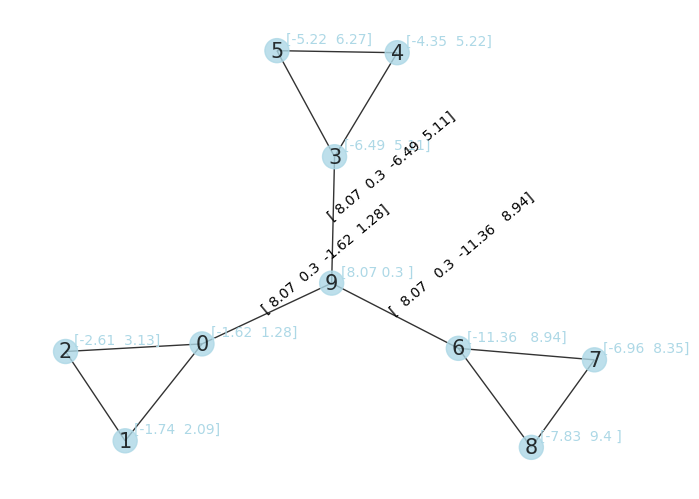

In [6]:
import numpy as np
# Use previous weight. W = np.random.normal(size=(num_features_level0,num_features_level1))
H = X@W
#print(H[9])
plt.figure()
nx.draw(pinwheel_graph,pos,with_labels = True,node_color = colormap, node_size = 300,font_size = 15, alpha=0.8)
neighbors = pinwheel_graph.neighbors(9)
concat9j = {neighbor: np.concatenate((H[9],H[neighbor])) for neighbor in neighbors}
#print(concat9j)
for node in pos.keys():
    plt.text(pos[node][0]+5, pos[node][1]+5, str(np.round(H[node,:],2)), color = "lightblue")
ax = plt.gca()
for neighbor in pinwheel_graph.neighbors(9):
    x = (pos[9][0] + pos[neighbor][0])/2
    y = (pos[9][1] + pos[neighbor][1])/2
    ax.text(x, y, str(np.round(concat9j[neighbor],2)), rotation = 40, rotation_mode = "anchor")

The labels on the edge are just the features of the two nodes connected together with each other. For example, the edge label for the edge connecting vertex 0 and vertex 9 is a vector made up of vertex 9's feature vector concatenated with vertex 3's feature vector. The features are shown in light blue so that you can confirm.

Let's check the dimensions, remembering that I'm using row vectors to represent features.

- Each feature vector is $1\times f$ where $f$ is the number of features.
- There are $n$ nodes
- The dimension of $X$, the vector formed by stacking all features, is $n\times f$
- The dimension of the weighted feature vector for each node is $1\times d$.
- The weight matrix $W$ is used in $XW$ so it must have dimension $f\times d$.

Stringing these pieces together means that $\vec{x}_iW$ is $1\times d$, so when we concatenate them we find the size of $\left[\vec{x}_i W \Vert \vec{x}_jW\right]$ to be $1\times 2d$.

---


**Restating the Problem to be Solved**

If you are like me, you've lost track of what we set out to do so let me remind you. We are trying to compute the attention coefficients $e_{ij}$ which tell node $i$ how much it should "pay attention" to neighbor $j$. We gave an abstract definition for how attention coefficients were computed

$$ e_{ij} = g(\vec{x}_i{\mathbf W}, \vec{x}_j {\mathbf W})$$

and are in the process of designing the function $g(\cdot)$. 

The function we'll use in this tutorial is defined using an intermediate variable, labeled $a_{ij}$, which is defined as

$$a_{ij} = \left[\vec{x}_i W \Vert \vec{x}_jW\right]W_{\rm att}$$

Since we want $a_{ij}$ to be a scalar and since we know the dimension of the concatenation vector, we set the dimension of $W_{\rm att}$ to $2d\times 1$. Observe that the same $W_{\rm att}$ is applied to each pair of nodes $\{i,j\}$. 

---


**Pinwheel Example**

Let's make up a random value for $W_{\rm att}$ and look at the values of $a_{ij}$ associated with node  9.

In [7]:
W_att = np.random.uniform(-1,1, (4,1))
print(W_att)

[[-0.04957282]
 [-0.84173472]
 [-0.60484274]
 [-0.94511028]]


Notice that $W_{\rm att}$ is a column vector.

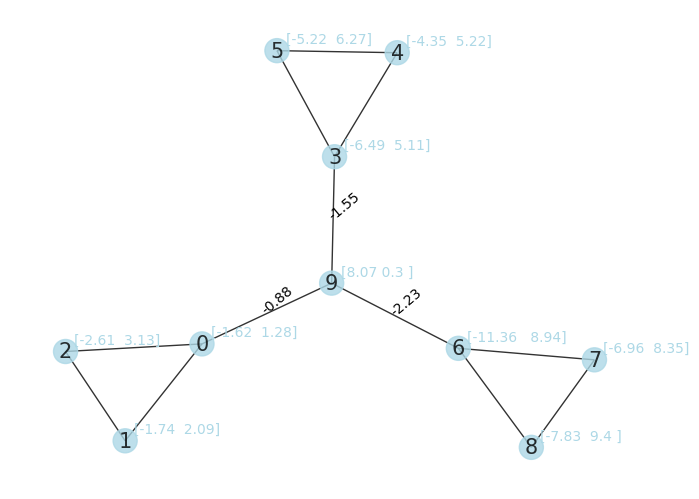

In [8]:
# Use previous weight. W = np.random.normal(size=(num_features_level0,num_features_level1))
H = X@W
plt.figure()
nx.draw(pinwheel_graph,pos,with_labels = True,node_color = colormap, node_size = 300,font_size = 15, alpha=0.8)
neighbors = pinwheel_graph.neighbors(9)
concat9j = {neighbor: np.concatenate((H[9],H[neighbor])) for neighbor in neighbors}
#print(concat9j)
for node in pos.keys():
    plt.text(pos[node][0]+5, pos[node][1]+5, str(np.round(H[node,:],2)), color = "lightblue")
ax = plt.gca()
for neighbor in pinwheel_graph.neighbors(9):
    x = (pos[9][0] + pos[neighbor][0])/2
    y = (pos[9][1] + pos[neighbor][1])/2
    a9j = concat9j[neighbor] @ W_att
    ax.text(x, y, str(np.round(a9j[0],2)), rotation = 40, rotation_mode = "anchor")

The concatenated vector on each edge has become a scalar.

---

**From $a_{ij}$ to $e_{ij}$**

We can now compute the attention coefficient. This is done by passing $a_{ij}$ through a nonlinear activation function. The original paper and both sources cited above use a [leaky rectified linear unit](https://en.wikipedia.org/wiki/Rectifier_(neural_networks)). This yields the attention coefficient

$$ e_{ij} = {\rm LeakyReLU}\left[ \vec{x}_iW \Vert \vec{x}_j W\right]W_{\rm att} $$

This nonlinearity is necessary, but I'll leave it to a different course to explain why.


In [9]:
def leaky_relu(x, alpha = 0.2):
    return np.maximum(alpha*x, x)

---

**Attention Coeficient in the Pinwheel Graph**

We can now plot the graph with the attention coefficients $e_{9j}$ around node 9.

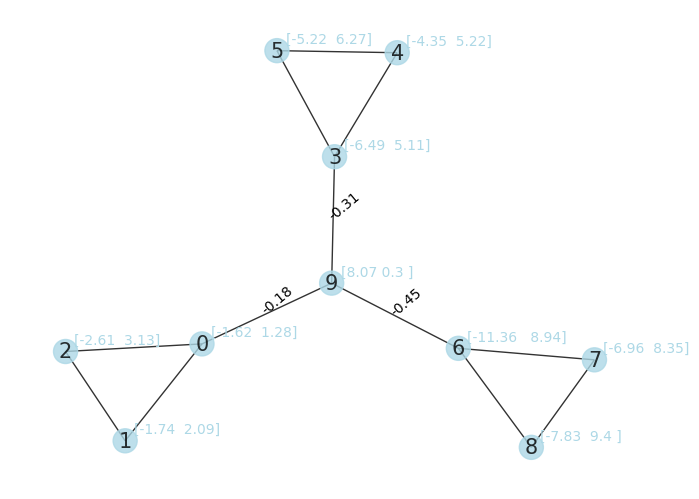

In [10]:
H = X@W
plt.figure()
nx.draw(pinwheel_graph,pos,with_labels = True,node_color = colormap, node_size = 300,font_size = 15, alpha=0.8)
neighbors = pinwheel_graph.neighbors(9)
concat9j = {neighbor: np.concatenate((H[9],H[neighbor])) for neighbor in neighbors}
#print(concat9j)
for node in pos.keys():
    plt.text(pos[node][0]+5, pos[node][1]+5, str(np.round(H[node,:],2)), color = "lightblue")
ax = plt.gca()
for neighbor in pinwheel_graph.neighbors(9):
    x = (pos[9][0] + pos[neighbor][0])/2
    y = (pos[9][1] + pos[neighbor][1])/2
    a9j = concat9j[neighbor] @ W_att
    e9j = leaky_relu(a9j)
    ax.text(x, y, str(np.round(e9j[0],2)), rotation = 40, rotation_mode = "anchor")

The values on the edges might not have changed, depending on what random matrices $W$ and $W_{\rm att}$ you had. If all the values $a_{ij}$ were positive, then there will be no change between the two previous figures.  

---


**Keeping Attention Coefficients Reasonable**

Notice that depending on the random weights, the values of $e_{ij}$ can be really big. This is a problem because it means that we cannot compare attention coefficients across different nodes. Quoting from the paper, "To make coefficients easily comparable across different nodes, we normalize them across all [neighbors of node $i$] using the softmax function".  This yields the _attention weights_,

$$  \begin{array}{lcr} \alpha_{ij}  &=& {\rm softmax}(e_{ij}) \\
        &=& \frac{{\rm exp}(e_{ij})}{\sum_{k\in N(i)} {\rm exp}(e_{ik})}
    \end{array} $$

---

**Define Softmax**

In [11]:
def softmax(e_vector):
    alpha = np.exp(e_vector)
    sum = np.sum(alpha)
    alpha = alpha/sum
    return alpha
e_vector = []
for neighbor in pinwheel_graph.neighbors(9):
    a9j = concat9j[neighbor] @ W_att
    e9j = leaky_relu(a9j)
    e_vector.append(e9j)
e_vector = softmax(e_vector)
print(e_vector)

neighbors = list(pinwheel_graph.neighbors(9))
alpha9 = {neighbors[i]:e_vector[i] for i in range(len(e_vector)) }
print(alpha9)

[[0.37929971]
 [0.33130936]
 [0.28939093]]
{0: array([0.37929971]), 3: array([0.33130936]), 6: array([0.28939093])}


**Softmax and the Pinwheel Graph**

Let's apply the softmax to the edge weights on the pinwheel graph.

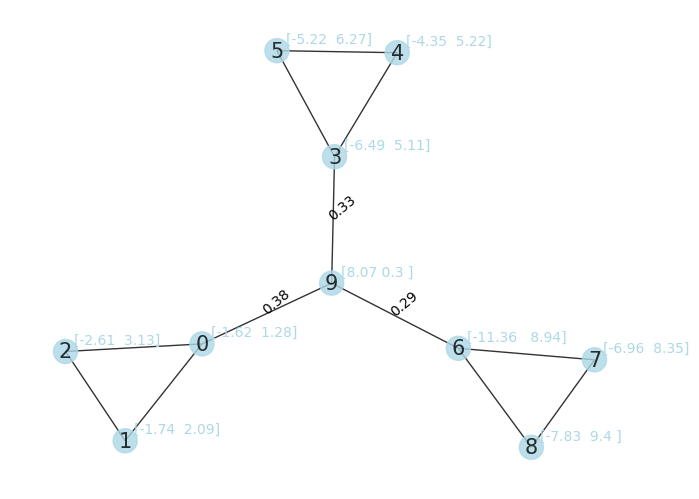

In [12]:
H = X@W
plt.figure()
nx.draw(pinwheel_graph,pos,with_labels = True,node_color = colormap, node_size = 300,font_size = 15, alpha=0.8)
neighbors = pinwheel_graph.neighbors(9)
concat9j = {neighbor: np.concatenate((H[9],H[neighbor])) for neighbor in neighbors}
#print(concat9j)
for node in pos.keys():
    plt.text(pos[node][0]+5, pos[node][1]+5, str(np.round(H[node,:],2)), color = "lightblue")
ax = plt.gca()
for neighbor in pinwheel_graph.neighbors(9):
    x = (pos[9][0] + pos[neighbor][0])/2
    y = (pos[9][1] + pos[neighbor][1])/2
    ax.text(x, y, str(np.round(alpha9[neighbor][0],2)), rotation = 40, rotation_mode = "anchor")

Notice how the attention weights sum to one.

---

#### Using the Attention Weights

We'll now receive the messages from node 9's neighbors, weight them by the attention weights, add them together, and show node 9's new feature. Note that we've used node 9's previous feature vector to compute the attention weights, so we won't need to add a self loop.

In [13]:
H = X@W
weighted_neighbor_features = [list(alpha9[neighbor]*H[neighbor]) for neighbor in pinwheel_graph.neighbors(9)]
#print(weighted_neighbor_features)
new_feature = np.sum(weighted_neighbor_features,axis=0)

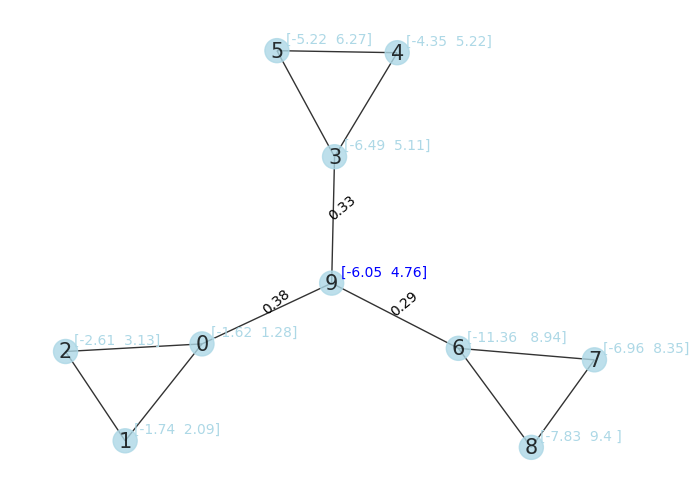

In [14]:
nx.draw(pinwheel_graph,pos,with_labels = True,node_color = colormap, node_size = 300,font_size = 15, alpha=0.8)
neighbors = pinwheel_graph.neighbors(9)
concat9j = {neighbor: np.concatenate((H[9],H[neighbor])) for neighbor in neighbors}
#print(concat9j)
for node in pos.keys():
    if node == 9:
        plt.text(pos[node][0]+5, pos[node][1]+5, str(np.round(new_feature,2)), color = "blue")
    else:
        plt.text(pos[node][0]+5, pos[node][1]+5, str(np.round(H[node,:],2)), color = "lightblue")
ax = plt.gca()
for neighbor in pinwheel_graph.neighbors(9):
    x = (pos[9][0] + pos[neighbor][0])/2
    y = (pos[9][1] + pos[neighbor][1])/2
    ax.text(x, y, str(np.round(alpha9[neighbor][0],2)), rotation = 40, rotation_mode = "anchor")

The value in the bright blue is the vector $\vec{h}_9$ for node 9. It was computed by
- Having all nodes compute $\vec{x}_j{\mathbf W}$
- Concatenating the resulting values of node 9 with its neighbors (index by $j$) to form $[\vec{x}_9{\mathbf W}\vert \vec{x}_j{\mathbf W}]$
- Computing $a_{9j}$ by multiplying this concatenated vector by the attention weights $W_{\rm att}$
- Passing $a_{9j}$ through the leaky RLU to compute edge weights $e_{9j}$
- Computing $\alpha_{9j}$ by passing $a_{9j}$ through a softmax to normalize its values
- Aggregating the values of node $9$'s neighbors using weighted sums where the weighting is $a_{9j}$

**Matrix Form**

We can put all the pieces together into a matrix equation by noting that all the summations over "neighbors of node $i$" can be implemented by including the adjacency matrix. We first collect all the values of $\alpha_{ij}$ into a new weight matrix. I'll separate the node indices by a comma to make things easier to read.

$$ W_\alpha = \left[\begin{array}{cccc}
    \alpha_{1,1} & \alpha_{1,2} & \ldots & \alpha_{1,n} \\
    \alpha_{2,1} & \alpha_{2,2} & \ldots & \alpha_{2,n} \\
    \vdots & \vdots & \ddots & \vdots \\
    \alpha_{n,1} & \alpha_{n,2} & \ldots & \alpha_{n,n}
\end{array}\right]$$

This matrix computes the attention weights for all node pairs, but that won't matter since we'll only use neighoring nodes. We can enforce this "neighbors only" condition by multiplying by the adjacency matrix.  This yields the matrix equation

$$ H = A W_{\alpha} X W $$

Where matrix $A$ has dimension $n\times n$, matrix $W_\alpha$ has dimension $n\times n$, matrix $X$ has dimension $n\times f$, and matrix $W$ has dimension $f\times d$. 

---

#### Demonstration using pytorch geometric

Code taken from the book by LaBonne, pates 114-115, which is cited above. I'll insert a few comments about some of the sophisticated ML components that are used but that are beyond the scope of this class.

__Step 1__

Get data from Cora database, which is already split it into training and testing sets and which has all nodes labeled.  The data is split into training and testing components. We train the data using only data from the training components. We report how well the training is going by looking at how well it performs on the testing components.

In [15]:
from torch_geometric.datasets import Planetoid

# Download the dataset
dataset = Planetoid(root=".",name="Cora")
# "Cora has only one graph we can store in a dedicated data variable", Lebonne p. 69
data = dataset[0]

print(data)

/Users/mike/Dropbox/Mac/Documents/Classes/CS 575/Winter 2026/Code/winter-2026-cs-575/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Data(x=[2708, 1433], edge_index=[2, 10556], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708])


In [16]:
print(data.y[data.train_mask])

tensor([3, 4, 4, 0, 3, 2, 0, 3, 3, 2, 0, 0, 4, 3, 3, 3, 2, 3, 1, 3, 5, 3, 4, 6,
        3, 3, 6, 3, 2, 4, 3, 6, 0, 4, 2, 0, 1, 5, 4, 4, 3, 6, 6, 4, 3, 3, 2, 5,
        3, 4, 5, 3, 0, 2, 1, 4, 6, 3, 2, 2, 0, 0, 0, 4, 2, 0, 4, 5, 2, 6, 5, 2,
        2, 2, 0, 4, 5, 6, 4, 0, 0, 0, 4, 2, 4, 1, 4, 6, 0, 4, 2, 4, 6, 6, 0, 0,
        6, 5, 0, 6, 0, 2, 1, 1, 1, 2, 6, 5, 6, 1, 2, 2, 1, 5, 5, 5, 6, 5, 6, 5,
        5, 1, 6, 6, 1, 5, 1, 6, 5, 5, 5, 1, 5, 1, 1, 1, 1, 1, 1, 1])


__Step 2__ 
Import the libraries we need.

In [17]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GATv2Conv
from torch.nn import Linear

- The _F_ package has member functions _log\_softmax_, _log\_elu_, and _dropout_ that we will use.
- The _Gatv2Conv_ package implements the matrix equation $ H = A W_{\alpha} X W $ 
- The _Linear_ package is just a linear layer 

You can read about dropout from a number of tutorials including a reasonably accessible one from [Medium](https://towardsdatascience.com/dropout-in-neural-networks-47a162d621d9). In effect, sometimes neural networks have so many parameters that they can memorize all of the training samples. This is called _overfitting_. Memorizing all the training samples is like learning not just the latent information in the training data but also the statistical noise. 

Dropout helps avoid this by randomly dropping a few nodes in the relevant layers, effectually decreasing the freedom of the network to overfit. Different nodes are dropped during different training intervals, forcing the remaining nodes to focus less on noise and more on the key parts of the information.

__Step 3__

Define an accuracy function that compares learned node labels to actual node labels. This will be used to show progress reports as the model learns.

In [18]:
def accuracy(y_pred, y_true):
    return torch.sum(y_pred==y_true) / len(y_true)

__Step 4__

Creat a graph attention network class using the _Gatv2Conv_ parent class from pytorch geometric. The model will have two graph attention network layers.

In [19]:
class GAT(torch.nn.Module):
    def __init__(self, dim_in, dim_h, dim_out, heads = 8):
        super().__init__()
        self.gat1 = GATv2Conv(dim_in, dim_h, heads = heads)
        self.gat2 = GATv2Conv(dim_h*heads, dim_out, heads = 1)


There is a new variable we haven't seen before: _heads_. Let's talk about a problem with the graph attention network performance and how _multi-head attention_ helps fix it.

The problem is, simply put, that there's a lot going on in this network. As a result, it's easy for the gradient descent process to just keep jumping around and never converge. Leskovec calls the network "finicky" (Lecture 7.2, minute24:38)[https://www.youtube.com/watch?v=247Mkqj_wRM] and discusses the solution.

The multi-head attention process says this: since it's sometimes hard to get the network to converge, let's lump a bunch of different network layers together, initialize each with a different weight, and then decide which of these different layers is working best. 

What this does in practice is to learn multiple copies of the attention weight matrix, $W_\alpha^1$, $W_\alpha^2$, $\ldots$, $W_{\alpha}^{\rm num_heads}$. The _heads_ parameter says how many attention weight matrices to learn. Each then reports back, and we through all of them into the next layer and let it select or blend the ones that are working well.

__Step 5__

We now create the overall architecture. LaBonne seems to have tried a bunch of settings and observed three things:
- First, the dropout mechanism described above is required to pervent overfitting.
- Second, an exponential version of the leaky ReLU seems to work better. 
- Third, a logarithmic version of softmax seems to work better than regular softmax.

I have no intuition about why one works better than another, so when I implement this in my own version of the final project I'll try to use these parameters too.

Recall that the overall architecture is specified in the _forward_ function that is called during learning.

In [20]:
def forward(self, x, edge_index):
    h = F.dropout(x, p=0.6, training = self.training)
    h = self.gat1(h, edge_index)
    h = F.elu(h)
    h = F.dropout(h, p=0.6, training = self.training)
    h = self.gat2(h, edge_index)
    out = F.log_softmax(h, dim=1)
    return out, h # both the learned class and the embedding are returned.

__Step 6__

Specify the training process. As part of this, state that we'll use the Adam optimizer and use cross entropy loss as the learning criterion.

In [21]:
def fit(self, data, epochs):
    optimizer = torch.optim.Adam(self.parameters(), lr=0.01, weight_decay=0.01)
    criterion = torch.nn.CrossEntropyLoss()

    self.train()
    for epoch in range(epochs+1):
        optimizer.zero_grad()
        out = self(data.x, data.edge_index)
        loss = criterion(out[data.train_mask], data.y[data.train_mask])
        acc = accuracy(out[data.train_mask].argmax(dim=1), data.y[data.train_maxk])
        loss.backward()
        optimizer.step()

        # Every now and then print out progress reports
        if epoch % 20 == 0:
            val_loss = criterion(out[data.val_mask], data.y[data.val_mask])
            val_acc = accuracy(out[data.val_mask].argmax(dim=1), data.y[data.val_mask])
            print(f"Epoch {epoch:>3} | Train Loss: {loss:.3f} | Train Acc: {acc*100:>5.2f}% | Val Loss {val_loss: .2f} | Val Acc: {val_acc*100:.2f}%")


__Step 7__

Define a test function to evaluate converence progress


In [22]:
@torch.no_grad()
def test(self, data):
    self.eval()
    out = self(data.x, data.edge_index)
    acc = accuracy(out.argmax(dim=1)[data.test_mask], data.y[data.test_mask])
    return acc

__Step 8__
Put all the functions in the same class instead of in separate cells. Note that I fixed some typos from the cells above when I put everything into the class.

In [23]:
class GAT(torch.nn.Module):
    def __init__(self, dim_in, dim_h, dim_out, heads = 8):
        super().__init__()
        self.gat1 = GATv2Conv(dim_in, dim_h, heads = heads)
        self.gat2 = GATv2Conv(dim_h*heads, dim_out, heads = 1)
        self.linear = Linear(dim_out, 2)
    
    def forward(self, x, edge_index):
        h = F.dropout(x, p=0.6, training = self.training)
        h = self.gat1(h, edge_index)
        h = F.elu(h)
        h = F.dropout(h, p=0.6, training = self.training)
        h = self.gat2(h, edge_index)
        embedding = h #self.linear(h)
        out = F.log_softmax(h, dim=1)
        return out, embedding # both the learned class and the embedding are returned.
    
    def fit(self, data, epochs):
        optimizer = torch.optim.Adam(self.parameters(), lr=0.01, weight_decay=0.01)
        criterion = torch.nn.CrossEntropyLoss()

        self.train()
        for epoch in range(epochs+1):
            optimizer.zero_grad()
            out, _ = self(data.x, data.edge_index)
            loss = criterion(out[data.train_mask], data.y[data.train_mask])
            acc = accuracy(out[data.train_mask].argmax(dim=1), data.y[data.train_mask])
            loss.backward()
            optimizer.step()

            # Every now and then print out progress reports
            if epoch % 20 == 0:
                val_loss = criterion(out[data.val_mask], data.y[data.val_mask])
                val_acc = accuracy(out[data.val_mask].argmax(dim=1), data.y[data.val_mask])
                print(f"Epoch {epoch:>3} | Train Loss: {loss:.3f} | Train Acc: {acc*100:>5.2f}% | Val Loss {val_loss: .2f} | Val Acc: {val_acc*100:.2f}%")
            
     

    @torch.no_grad()
    def test(self, data):
        self.eval()
        out, _ = self(data.x, data.edge_index)
        acc = accuracy(out.argmax(dim=1)[data.test_mask], data.y[data.test_mask])
        return acc

__Step 9__

Create the graph attention network and run for 100 epochs

In [24]:
gat = GAT(dataset.num_features, 32, dataset.num_classes)
gat.fit(data, epochs = 200)

Epoch   0 | Train Loss: 1.932 | Train Acc: 17.14% | Val Loss  1.94 | Val Acc: 15.00%
Epoch  20 | Train Loss: 0.225 | Train Acc: 99.29% | Val Loss  0.86 | Val Acc: 72.60%
Epoch  40 | Train Loss: 0.172 | Train Acc: 99.29% | Val Loss  0.87 | Val Acc: 74.20%
Epoch  60 | Train Loss: 0.167 | Train Acc: 97.14% | Val Loss  0.88 | Val Acc: 71.00%
Epoch  80 | Train Loss: 0.196 | Train Acc: 98.57% | Val Loss  0.93 | Val Acc: 71.80%
Epoch 100 | Train Loss: 0.172 | Train Acc: 99.29% | Val Loss  0.91 | Val Acc: 73.80%
Epoch 120 | Train Loss: 0.156 | Train Acc: 97.86% | Val Loss  0.92 | Val Acc: 71.60%
Epoch 140 | Train Loss: 0.186 | Train Acc: 97.14% | Val Loss  0.88 | Val Acc: 74.80%
Epoch 160 | Train Loss: 0.137 | Train Acc: 98.57% | Val Loss  1.01 | Val Acc: 68.40%
Epoch 180 | Train Loss: 0.199 | Train Acc: 96.43% | Val Loss  0.99 | Val Acc: 72.80%
Epoch 200 | Train Loss: 0.177 | Train Acc: 95.71% | Val Loss  0.97 | Val Acc: 72.20%


In [25]:
out, embedding = gat(data.x, data.edge_index)

In [26]:
print(embedding.detach().numpy().shape)
print(embedding.detach().numpy())


(2708, 7)
[[-2.3077452  -0.19783266 -2.0732136  ...  0.4505862  -0.5933844
  -2.7853374 ]
 [ 3.3053336  -2.341491   -2.7148092  ...  6.8984985  -0.3229759
  -2.8863878 ]
 [ 0.52571285 -1.3264823  -1.7663554  ...  5.3698325  -1.9525958
  -1.5904241 ]
 ...
 [ 1.7593678   0.60246956 -2.3345602  ... -1.229676    0.83283246
  -0.44370544]
 [-1.3627825  -0.29077503  0.15202692 ...  0.3949163  -2.5637867
  -2.0515919 ]
 [-1.6370378  -0.07042862  0.29497948 ...  0.6767459  -2.6951663
  -2.3998485 ]]


In [27]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

label_dict = {
    0: "Theory",
    1: "Reinforcement_Learning",
    2: "Genetic_Algorithms",
    3: "Neural_Networks",
    4: "Probabilistic_Methods",
    5: "Case_Based",
    6: "Rule_Learning"}

colorlist = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00', '#ffff33', '#a65628']


def visualize(h):
    z = TSNE(n_components=2).fit_transform(h)

    plt.figure(figsize=(10,10))
    plt.xticks([])
    plt.yticks([])

    for class_number in label_dict.keys():
        index_list = extract_nodes_by_class(data.y,class_number)
        plt.scatter(z[index_list, 0], z[index_list, 1], s=70, c=colorlist[class_number], cmap="Set2")

    #plt.scatter(z[:, 0], z[:, 1], s=70, c=color, cmap="Set2")
    _ = plt.legend(["Theory", "Reinforcement_Learning", "Genetic_Algorithms",
                    "Neural_Networks", "Probabilistic_Methods",
                    "Case_Based", "Rule_Learning"],bbox_to_anchor=(1, 1), loc='upper left')
    plt.show()

def extract_nodes_by_class(data,class_number):
    index_list = []
    for index, item in enumerate(data):
        if data[index] == class_number:
            index_list.append(index)
    return index_list


/var/folders/7n/9nnbl1td6sq50rrh09m9x1v80000gn/T/ipykernel_36548/2422878464.py:25: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(z[index_list, 0], z[index_list, 1], s=70, c=colorlist[class_number], cmap="Set2")


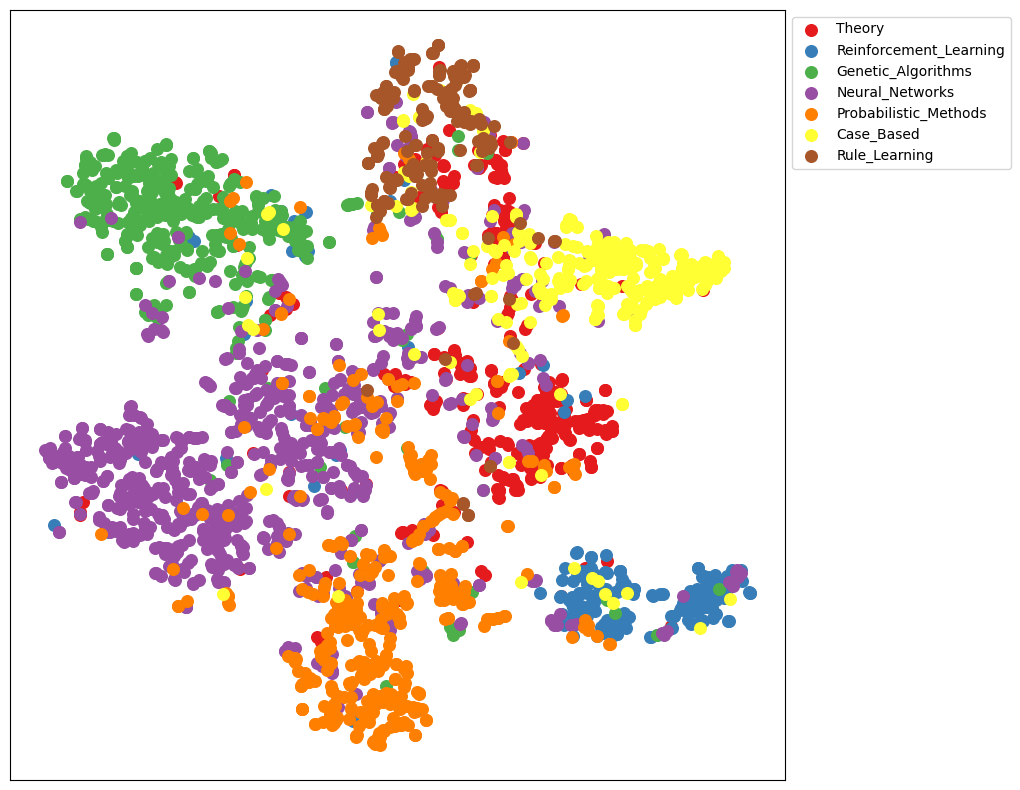

In [28]:
visualize(embedding.detach().numpy())

---

Check out Leskovec's discussion of the benefits of the attention mechanism in [Lecture 7.2, minute27.26](https://www.youtube.com/watch?v=247Mkqj_wRM)